In [1]:
import sys
import os

sys.path.append(os.path.abspath('./predictability_emergence')) 

import DataMakar
import DataHolder
import buildmodel
import helpers

import importlib as imp
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch.optim as optim

import torch.optim.lr_scheduler as lr_scheduler
import time

import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

import glob
import json
import pickle
from scipy.stats import percentileofscore
from statsmodels.stats.contingency_tables import mcnemar

from PIL import Image

import cartopy.crs as ccrs
import matplotlib as mpl
from matplotlib.colors import BoundaryNorm
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

mpl.rcParams['figure.facecolor'] = 'white'
mpl.rcParams['figure.dpi'] = 150
mpl.rcParams['font.family'] = 'sans-serif'
mpl.rcParams['font.size'] = 12
mpl.rcParams['font.sans-serif']=['Verdana']

params = {"ytick.color": "k",
          "xtick.color": "k",
          "axes.labelcolor": "k",
          "axes.edgecolor": "k"}
plt.rcParams.update(params)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import joblib

In [46]:
ssplist = ["370"]

ssplistplot = ["hist","370"] # thank god i haven't flipflopped on ssp labeling! that would be so annoying

# set user parameters

experiment_era = [1970,2025]
baselineera = [1900,1950]
trainvaltest = [np.arange(25),np.arange(25,38),np.arange(38,50)]

experiment_era_obs = [1970,2025]
baselineera_obs = [1950,1980]

inputlength = 10
outputavgtime = 5
# data params
outres = 10
timerange = [1900,2100]
filefront = "MPI_"
modelfilefront = "MPI_recordtemp_"
annmodelfilefront = "MPI_recordtemp_nosst"
inres = 4
inputvar = 'tos'
outputvar = 'tas'
obstimerange = [1940,2025]
data_dir = 'data'

seedlist = [62469869,
            71856281,
            47621498,
            10431957,
            50561320,
            72166634,
            18469465,
            92895735,
            57693846,
            22284750]

imp.reload(DataHolder)

params = {
    "outres": outres,
    "timerange": timerange,
    "filefront": filefront,
    "inres": inres,
    "inputvar":inputvar,
    "outputvar":outputvar,
    "seedlist": seedlist,
    "obstimerange":obstimerange,
    "data_dir":data_dir
}

ntrain = 25
nval = 13
test = np.arange(38,50)

n_best = 3

#get the data

AllData = DataHolder.MPIInputOutput_SSPlist(params,ssplist)

latvec = AllData.output_lat
lonvec = AllData.output_lon

lonmesh,latmesh = np.meshgrid(lonvec+5,latvec+5)

device = 'mps'


data/MPI_annualmean_370_tos_1900-2100.pkl


SyntaxError: closing parenthesis ']' does not match opening parenthesis '(' (1939400165.py, line 83)

In [56]:
lat = 40
lon = 20

_, allval, _ = AllData.trainvaltest_recordmax_withrecordmax(trainvaltest,experiment_era,baselineera,inputlength,outputavgtime,lat,lon)

inputval, inputvalGMT, outputval = DataHolder.tensortime_onehot_withrecordmax(allval,nclasses=2)

valtrueclass = np.argmax(outputval.numpy(),axis=1)
allvaltrue = valtrueclass

valimbalance = np.mean(outputval[:,1].numpy())
valimbalance = [float((1-valimbalance)),float(valimbalance)]

    # load the model

loadfile = "models/"+ modelfilefront+ "avgtime_"+ str(outputavgtime)+ "_allssps_lat_"+ str(lat)+ "_lon_"+ str(lon)+ "_seed_"+ str(seed)+ ".pt"
cnn = buildmodel.CNNclassifier(inputval, inputvalGMT, 2).to('cpu')
cnn.load_state_dict(torch.load(loadfile,map_location=torch.device('cpu'), weights_only=False))
cnn.to(device)

annloadfile = "models/"+annmodelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_lat_"+str(lat)+"_lon_"+str(lon)+"_seed_"+str(seed)+".pt"
ann = buildmodel.ANNclassifier(inputvalGMT, 2).to('cpu')
ann.load_state_dict(torch.load(annloadfile,map_location=torch.device('cpu'), weights_only=False))
ann.to(device)

with torch.no_grad():
    cnn.eval()
    valpred = cnn(inputval.to(device), inputvalGMT.to(device)).cpu().numpy()

    ann.eval()
    valpred_ann = ann(inputvalGMT.to(device)).cpu().numpy()

allvalpred = valpred[:,1]
allvalpred_ann = valpred_ann[:,1]

# predmean = np.mean(allvalpred,axis=0) # confidence in positive class
# predclass = np.round(predmean) # prediction class
# predconf = np.where(predmean<0.5,1-predmean,predmean)

baseline for temp records is 0 50
indices of future period are 104 -4
working on 370


In [57]:
def f1_threshold_grid(scores, y, thresholds=np.linspace(0.01, 0.99, 99)):
    """Direct version: evaluate F1 at each threshold on a grid via broadcasting."""
    s = scores[None, :]               # shape (1, n)
    t = thresholds[:, None]           # shape (T, 1)
    pos = (y == 1)[None, :]           # shape (1, n)

    pred = s >= t                     # shape (T, n): row k = decisions at threshold k

    tp = np.sum(pred & pos, axis=1)   # predicted 1, actually 1
    fp = np.sum(pred & ~pos, axis=1)  # predicted 1, actually 0
    fn = np.sum(~pred & pos, axis=1)  # predicted 0, actually 1

    denom = 2 * tp + fp + fn
    f1 = np.where(denom > 0, 2 * tp / np.maximum(denom, 1), 0.0)

    k = np.argmax(f1)
    return thresholds[k], f1[k], f1

In [67]:
a,b,c=f1_threshold_grid(allvalpred_ann, valtrueclass, thresholds=np.linspace(0.05, 0.95, 20))

In [68]:
c

array([0.57676349, 0.60263362, 0.62272333, 0.625     , 0.59414226,
       0.56633222, 0.55222089, 0.51604621, 0.47606019, 0.44126074,
       0.39940387, 0.3622291 , 0.31612903, 0.28093645, 0.25172414,
       0.22775801, 0.2047532 , 0.18113208, 0.1372549 , 0.0698152 ])

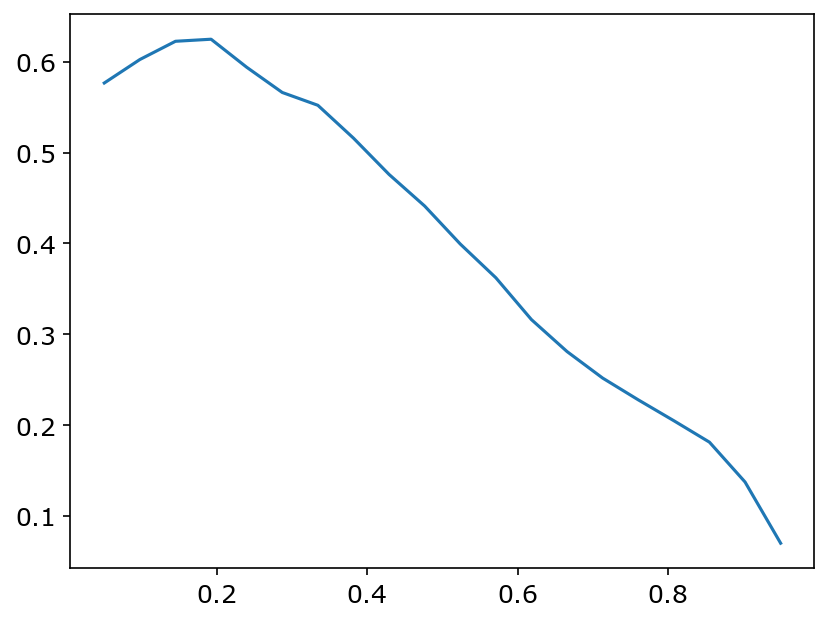

In [69]:
plt.plot(np.linspace(0.05, 0.95, 20),c)

In [23]:
predmean.shape

()

(array([1038.,  136.,   76.,   52.,   52.,   37.,   26.,   19.,    9.,
          11.]),
 array([1.18145428e-04, 8.25656876e-02, 1.65013239e-01, 2.47460783e-01,
        3.29908341e-01, 4.12355870e-01, 4.94803429e-01, 5.77250957e-01,
        6.59698486e-01, 7.42146075e-01, 8.24593604e-01]),
 <BarContainer object of 10 artists>)

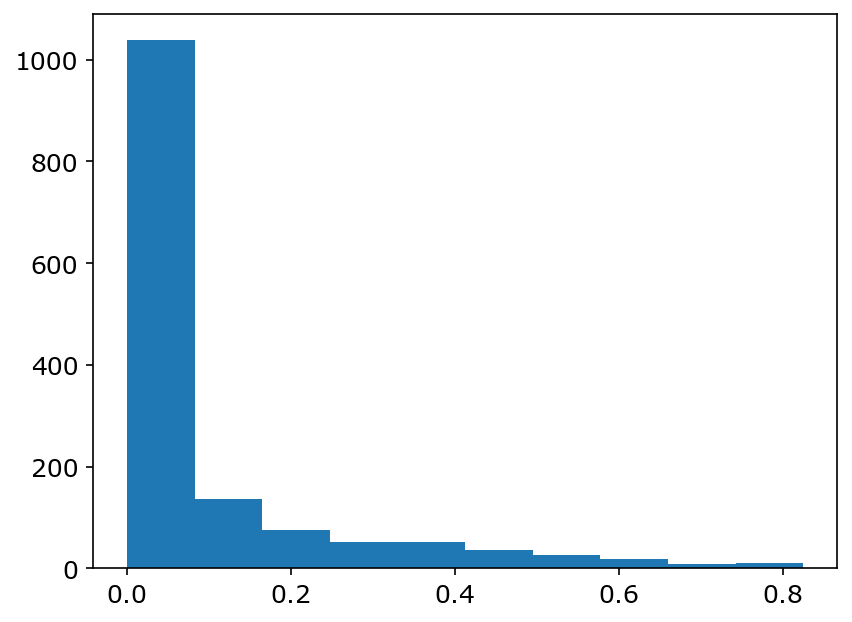

In [15]:
plt.hist(allvalpred_ann)

In [3]:

imp.reload(DataHolder)
AllObs = DataHolder.ERA5InputOutput(params)

lenobs = experiment_era_obs[1]-experiment_era_obs[0]-outputavgtime-inputlength+1

In [4]:
landmask = np.isnan(np.nanmean(AllObs.alloutput,axis=0))

In [158]:
def expectedcalibrationerror(pred,true,interval):

    confints = np.arange(0,1,interval)

    calibcurve = np.empty(len(confints))
    nsamps = np.empty(len(confints))

    for isel,ii in enumerate(confints):

        MPIsel = (pred>ii) & (pred<(ii+interval))
        calibcurve[isel] = np.mean(true[MPIsel])

        nsamps[isel] = len(true[MPIsel])

    ece = np.sum(nsamps*np.abs(calibcurve-confints))/len(pred)

    return ece,calibcurve

def adaptivecalibrationerror(pred,true,interval):

    confints = np.arange(0,1,interval)
    calibcurve = np.empty(len(confints))

    for iper,per in enumerate(confints):

        MPIq = np.percentile(pred,q=100*per)
        MPIq1 = np.percentile(pred,q=100*(per+interval))
        MPIsel = (pred>MPIq) & (pred<(MPIq1))

        calibcurve[iper] = np.mean(true[MPIsel])

    ace = np.mean(calibcurve)

    return ace

def posneg_calib(pred,true):

    predneg = pred<0.5
    predpos = pred>=0.5

    nneg = 1-np.mean(1*true[predneg])
    npos = np.mean(1*true[predpos])

    posnegdiff = npos-nneg
    return [nneg,npos]


def f1_threshold_grid(preds, true, thresholds=np.linspace(0.01, 0.99, 99)):
    """Direct version: evaluate F1 at each threshold on a grid via broadcasting."""
    s = preds[None, :]               # shape (1, n)
    t = thresholds[:, None]           # shape (T, 1)
    pos = (true == 1)[None, :]           # shape (1, n)

    predsel = s >= t                     # shape (T, n): row k = decisions at threshold k

    tp = np.sum(predsel & pos, axis=1)   # predicted 1, actually 1
    fp = np.sum(predsel & ~pos, axis=1)  # predicted 1, actually 0
    fn = np.sum(~predsel & pos, axis=1)  # predicted 0, actually 1

    denom = 2 * tp + fp + fn
    f1 = np.where(denom > 0, 2 * tp / np.maximum(denom, 1), 0.0)

    k = np.argmax(f1)
    return thresholds[k], f1[k], f1


In [124]:
filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_70_testing.pkl"
with open(filepredictions,'rb') as f:
    predictions = pickle.load(f)

In [150]:
ece = np.empty((18,36))
ece_ann = np.empty((18,36))

ace = np.empty((18,36))
ace_ann = np.empty((18,36))

preddiff = np.empty((18,36,2))
preddiff_ann = np.empty((18,36,2))

for ilatsel,latsel in enumerate(np.arange(-90,90,10)):

    filepredictions = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_testing.pkl"
    annfilepredictions = "predictions/"+annmodelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_testing.pkl"
    filecheck = glob.glob(filepredictions)

    if len(filecheck)>0:

        with open(filepredictions,'rb') as f:
            predictions = pickle.load(f)

        with open(annfilepredictions,'rb') as f:
            annpredictions = pickle.load(f)

        filetrue = "predictions/"+modelfilefront+"avgtime_"+str(outputavgtime)+"_allssps_allseeds_lat_"+str(latsel)+"_truetesting.pkl"

        with open(filetrue,'rb') as f:
            truths = pickle.load(f)

        meanpred = np.nanmean(predictions,axis=1)
        annmeanpred = np.nanmean(annpredictions,axis=1)

        for ilon in np.arange(36):
            ece[ilatsel,ilon],_ = expectedcalibrationerror(meanpred[ilon],truths[ilon],0.1)
            ece_ann[ilatsel,ilon],_ = expectedcalibrationerror(annmeanpred[ilon],truths[ilon],0.1)

            ace[ilatsel,ilon] = adaptivecalibrationerror(meanpred[ilon],truths[ilon],0.1)
            ace_ann[ilatsel,ilon] = adaptivecalibrationerror(annmeanpred[ilon],truths[ilon],0.1)

            preddiff[ilatsel,ilon] = posneg_calib(meanpred[ilon],truths[ilon])
            preddiff_ann[ilatsel,ilon] = posneg_calib(annmeanpred[ilon],truths[ilon])

ece[:2,:] = np.nan
ece_ann[:2,:] = np.nan



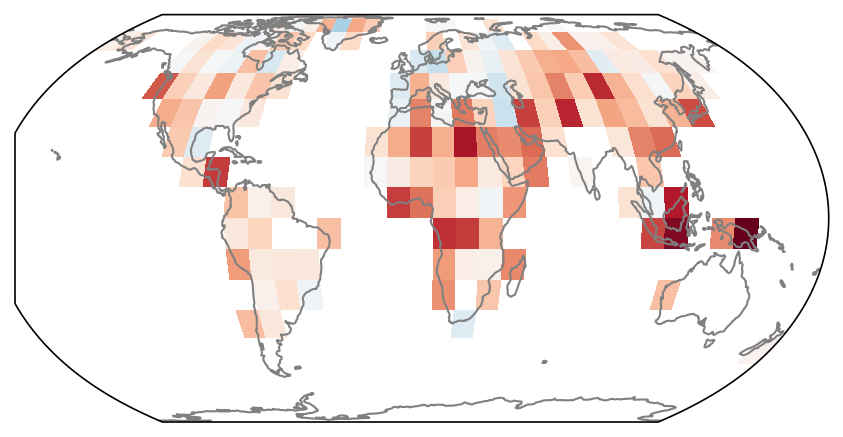

In [143]:
plt.figure(figsize=(7,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,ece_ann-ece,vmin=-0.05,vmax=0.05,cmap='RdBu_r',transform=ccrs.PlateCarree())
ax.coastlines(color='grey')

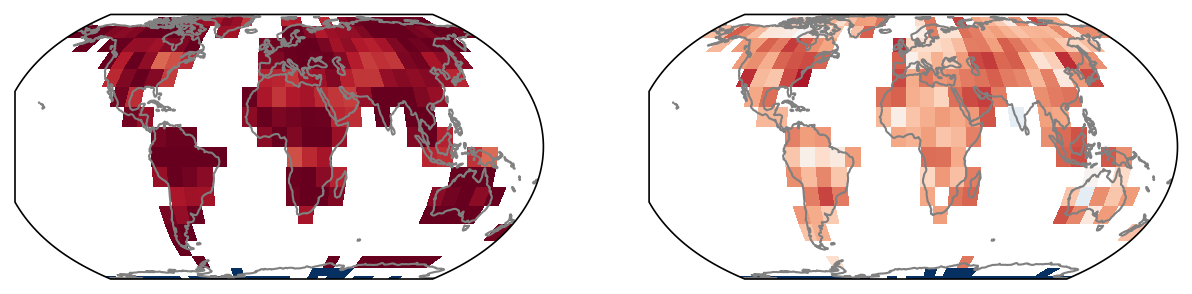

In [157]:
plt.figure(figsize=(10,4))
ax=plt.subplot(1,2,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,preddiff_ann[:,:,0],vmin=0.2,vmax=0.8,cmap='RdBu_r',transform=ccrs.PlateCarree())
ax.coastlines(color='grey')
ax=plt.subplot(1,2,2,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,preddiff_ann[:,:,1],vmin=0.2,vmax=0.8,cmap='RdBu_r',transform=ccrs.PlateCarree())
ax.coastlines(color='grey')

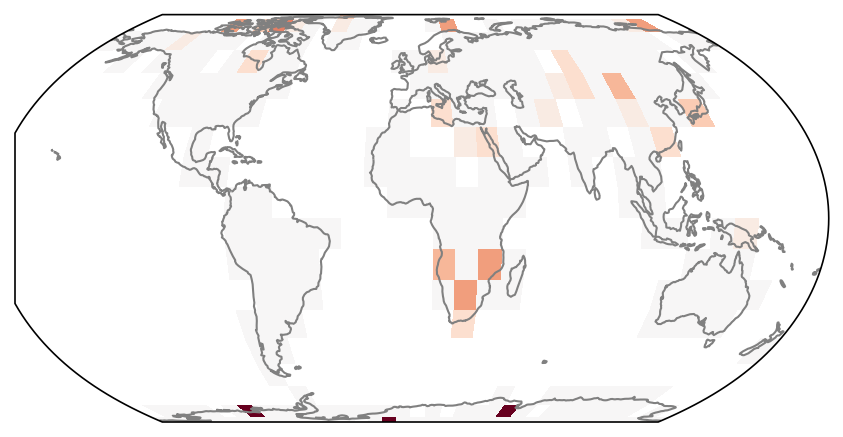

In [128]:
plt.figure(figsize=(7,4))
ax=plt.subplot(1,1,1,projection=ccrs.EqualEarth())
ax.pcolormesh(lonvec+5,latvec+5,ace_ann,vmin=-0.3,vmax=0.3,cmap='RdBu_r',transform=ccrs.PlateCarree())
ax.coastlines(color='grey')

In [ ]:
import numpy as np

def f1_threshold_grid(scores, y, thresholds=np.linspace(0.01, 0.99, 99)):
    """Direct version: evaluate F1 at each threshold on a grid via broadcasting."""
    s = scores[None, :]               # shape (1, n)
    t = thresholds[:, None]           # shape (T, 1)
    pos = (y == 1)[None, :]           # shape (1, n)

    pred = s >= t                     # shape (T, n): row k = decisions at threshold k

    tp = np.sum(pred & pos, axis=1)   # predicted 1, actually 1
    fp = np.sum(pred & ~pos, axis=1)  # predicted 1, actually 0
    fn = np.sum(~pred & pos, axis=1)  # predicted 0, actually 1

    denom = 2 * tp + fp + fn
    f1 = np.where(denom > 0, 2 * tp / np.maximum(denom, 1), 0.0)

    k = np.argmax(f1)
    return thresholds[k], f1[k], f1


def f1_threshold_exact(scores, y):
    """Exact version: every distinct score is a candidate threshold.
    Sort scores descending; lowering the threshold past each point
    adds it to the predicted positives, so TP and FP are cumulative sums."""
    order = np.argsort(-scores)
    s, yy = scores[order], y[order]

    tp = np.cumsum(yy == 1)           # TP if threshold = s[i] (top i+1 predicted positive)
    fp = np.cumsum(yy == 0)
    fn = np.sum(y == 1) - tp          # positives not yet captured

    # keep only the last index of each tied score (ties must switch together)
    last = np.r_[s[1:] != s[:-1], True]
    tp, fp, fn, s = tp[last], fp[last], fn[last], s[last]

    f1 = 2 * tp / (2 * tp + fp + fn)
    k = np.argmax(f1)
    return s[k], f1[k]


# --- example with imbalanced synthetic data ---
rng = np.random.default_rng(0)
n = 5000
y = (rng.random(n) < 0.05).astype(int)            # 5% positives
# overconfident scores, like a class-weighted model
scores = 1 / (1 + np.exp(-(2.5 * y - 0.5 + rng.normal(0, 1, n))))

t_grid, f1_grid, curve = f1_threshold_grid(scores, y)
t_exact, f1_exact = f1_threshold_exact(scores, y)
f1_at_half = curve[np.argmin(np.abs(np.linspace(0.01, 0.99, 99) - 0.5))]

print(f"grid:  t* = {t_grid:.3f}, F1 = {f1_grid:.3f}")
print(f"exact: t* = {t_exact:.3f}, F1 = {f1_exact:.3f}")
print(f"F1 at t = 0.5: {f1_at_half:.3f}")